# Does converged ALF-LB price experts the way the congestion game does?

**One thread through the evidence.** Every number below is read from a committed CSV in
`assets/results/`, which is the authoritative copy rather than one of two. `assets/results/README.md`
records the gitignored working file each one came from and how to detect drift between them. Nothing
here re-solves an LP or touches a checkpoint, so the whole notebook runs on a laptop in a few
seconds.

**To run it:** install the extra dependencies once with `uv sync --inexact --group analysis`, then
open this file in VS Code, select `.venv/bin/python` as the kernel and press *Run All*. `--inexact`
matters, because a plain `uv sync` prunes the Transformer Engine stack that lives outside the lock
and the `megatron.core` tests then skip instead of running.

The figures render inline and their outputs are committed with the notebook, so this file is the
artifact rather than a script that produces one. To re-execute it without opening an editor:

```
uv run --group analysis jupyter nbconvert --to notebook --execute --inplace \
  notebooks/alflb_price_internalization.ipynb
```

## The claim, in one paragraph

ALF-LB learns a per-expert bias `b_train`, and the congestion game says a batch's equilibrium price
is the LP's capacity dual `p*(B)`. Neither is the object of interest. The **population price**
`p_bar` is, and nothing observes it. What is measurable is `kappa = corr(b_train, p_bar)`, recovered
from two pool-disjoint batches with no free parameter.


In [1]:
import csv
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def repo_root():
    """Find the checkout from the kernel's cwd, which differs between VS Code and nbconvert."""
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "assets" / "results" / "MANIFEST.csv").is_file():
            return base
    raise FileNotFoundError("run this notebook from inside the checkout")


RESULTS = repo_root() / "assets" / "results"
ETA = 1.0e-3

# Slots 1 and 2 of the reference categorical palette, in fixed order and unmodified.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, FAINT = "#0b0b0b", "#52514e", "#c9c8c4"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": FAINT,
        "axes.labelcolor": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#ecebe8",
        "grid.linewidth": 0.8,
        "text.color": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
    }
)


def load(name):
    with open(RESULTS / name) as handle:
        return list(csv.DictReader(handle))


def num(row, key):
    value = row[key]
    return float(value) if value not in ("", None) else float("nan")


manifest = load("MANIFEST.csv")
for tier in ("headline", "supporting", "provenance", "superseded"):
    picked = [m for m in manifest if m["tier"] == tier]
    print(f"\n{tier.upper()} ({len(picked)})")
    for m in picked:
        note = f"   <- use {m['superseded_by']}" if m["superseded_by"] else ""
        print(f"  {m['file']}{note}")


HEADLINE (6)
  kappa-trajectory_cross-asset_21-steps.csv
  crossprobe_2x2_matched-16384_step500.csv
  bias-jitter_both-runs_per-layer.csv
  load-screen_training_both-runs_21-steps.csv
  verification_tail-probe_step500_annealed4000.csv
  crossprobe_per-expert-prices_step500.csv

SUPPORTING (11)
  half-split_strided-probe_bootstrap_4-steps.csv
  internalization_strided-probe_per-half_5-steps.csv
  load-screen_crossprobe_halves.csv
  internalization_both-probes_bias-swap_run-decoupling.csv
  price-spread_both-probes_trajectory.csv
  internalization_tail-probe_all-steps.csv
  synthetic-grid_alflb-vs-lp_48-instances.csv
  price-stability_strided-probe_sequence_parts4.csv
  price-stability_tail-probe_sequence_parts4.csv
  price-stability_tail-probe_random_parts4.csv
  price-stability_tail-probe_stride_parts4.csv

PROVENANCE (1)
  crosscheck_platform_strided-probe_step500.csv

SUPERSEDED (5)
  price-stability_strided-probe_sequence_parts2.csv   <- use crossprobe_2x2_matched-16384_step500.csv

---
## 1. The gate: which batches are allowed to have a price at all

A price describes a batch the router treated as a **sample**. When one expert takes most of a
batch's tokens the LP must price it far from the rest simply to shed them, and that price then
describes the concentration rather than the population.

The screen refuses on two counts. An expert that receives **zero** tokens has no capacity
constraint to price, so the LP is free to give it any dual at all, which makes the refusal true by
construction rather than a judgement about the batch. That is what does most of the refusing at
steps 25 and 50, where up to 32 of 64 experts are unvisited. The second count is concentration:
`max deployed load / L`, with `L = n*K/E`, catches it from the routing map alone and needs no LP.
It is a **refusing** gate at 3.5, and a refused unit is emitted with `admissible = False` and NaN
statistics rather than dropped, so an exclusion never reads downstream as an absence of signal. The
threshold is calibrated across 344 units: the worst unit that behaves reads 3.26 and the mildest
distorted one 4.04.

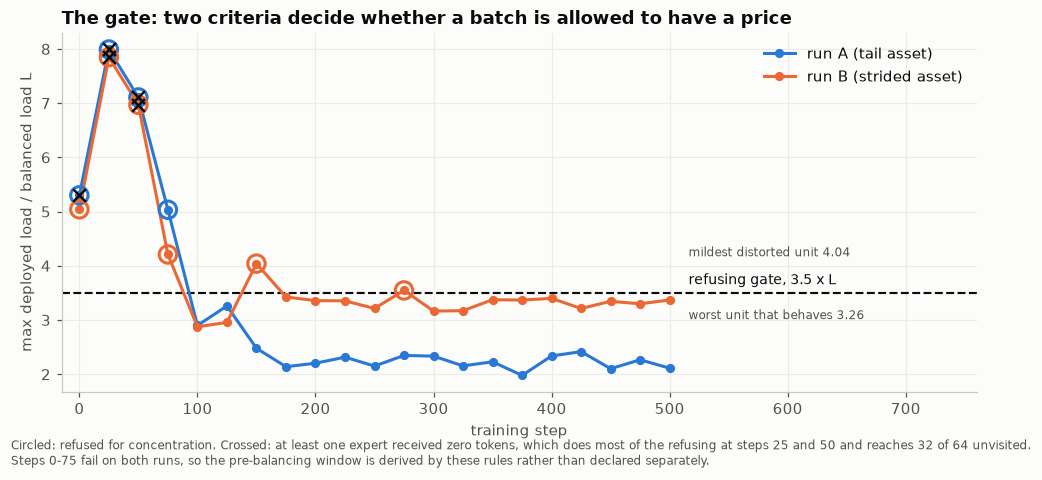

In [2]:
rows = load("load-screen_training_both-runs_21-steps.csv")
LIMIT = 3.5
runs = {
    "20260819-195028": ("run A (tail asset)", BLUE),
    "20260824-232033": ("run B (strided asset)", ORANGE),
}

fig, ax = plt.subplots(figsize=(9, 4.2))
for key, (label, colour) in runs.items():
    worst = defaultdict(float)
    for r in rows:
        if key in r["dump"]:
            worst[int(r["step"])] = max(worst[int(r["step"])], num(r, "max_load_over_balanced"))
    dead = defaultdict(int)
    for r in rows:
        if key in r["dump"]:
            dead[int(r["step"])] += int(r["dead_experts"])
    steps = sorted(worst)
    values = [worst[s] for s in steps]
    ax.plot(steps, values, "-o", color=colour, lw=2, ms=5, label=label, zorder=3)
    bad = [(s, v) for s, v in zip(steps, values, strict=True) if v > LIMIT]
    if bad:
        ax.scatter(
            [b[0] for b in bad],
            [b[1] for b in bad],
            s=130,
            facecolor="none",
            edgecolor=colour,
            lw=2,
            zorder=4,
        )

    starved = [(s, v) for s, v in zip(steps, values, strict=True) if dead[s]]
    if starved:
        ax.scatter(
            [b[0] for b in starved],
            [b[1] for b in starved],
            marker="x",
            s=70,
            color=INK,
            lw=1.6,
            zorder=5,
        )

worst_starved = max(int(r["dead_experts"]) for r in rows)
ax.axhline(LIMIT, color=INK, lw=1.4, ls="--", zorder=2)
ax.annotate(f"refusing gate, {LIMIT} x L", (516, LIMIT + 0.1), va="bottom", fontsize=9, color=INK)
ax.annotate("worst unit that behaves 3.26", (516, 3.20), va="top", fontsize=8, color=MUTED)
ax.annotate("mildest distorted unit 4.04", (516, 4.12), va="bottom", fontsize=8, color=MUTED)
ax.set_xlabel("training step")
ax.set_ylabel("max deployed load / balanced load L")
ax.set_title("The gate: two criteria decide whether a batch is allowed to have a price")
ax.set_xlim(-15, 760)
ax.legend(frameon=False, loc="upper right")
fig.text(
    0.008,
    -0.02,
    "Circled: refused for concentration. Crossed: at least one expert received zero tokens, "
    f"which does most of the refusing at steps 25 and 50 and reaches {worst_starved} of 64 "
    "unvisited.\nSteps 0-75 fail on both runs, so the pre-balancing window is derived by these "
    "rules rather than declared separately.",
    fontsize=8,
    color=MUTED,
)
fig.tight_layout()
plt.show()

---
## 2. What a refused batch looks like, expert by expert

Each point is one expert. The axes are two batches scored on the same weights at the same step.

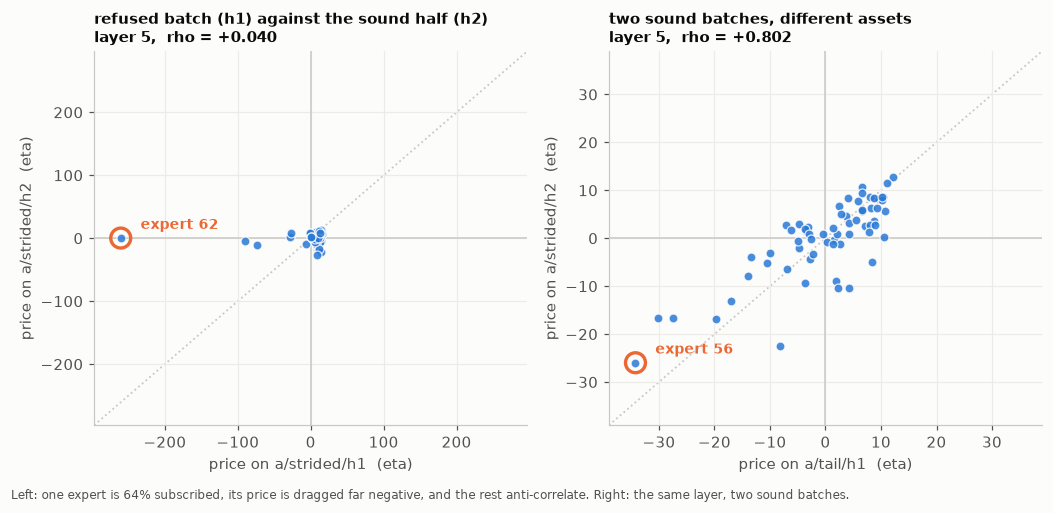

In [3]:
prices = load("crossprobe_per-expert-prices_step500.csv")


def price_vector(unit, layer):
    picked = [r for r in prices if r["unit"] == unit and int(r["layer"]) == layer]
    picked.sort(key=lambda r: int(r["expert"]))
    return np.array([num(r, "price") for r in picked]) / ETA


panels = [
    ("a/strided/h1", "a/strided/h2", "refused batch (h1) against the sound half (h2)"),
    ("a/tail/h1", "a/strided/h2", "two sound batches, different assets"),
]
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.5))
for ax, (unit_a, unit_b, title) in zip(axes, panels, strict=True):
    x, y = price_vector(unit_a, 5), price_vector(unit_b, 5)
    r = np.corrcoef(x, y)[0, 1]
    lim = float(np.abs(np.r_[x, y]).max()) * 1.14
    ax.axhline(0, color=FAINT, lw=1)
    ax.axvline(0, color=FAINT, lw=1)
    ax.plot([-lim, lim], [-lim, lim], color=FAINT, lw=1.2, ls=":", zorder=1)
    ax.scatter(x, y, s=34, color=BLUE, alpha=0.85, edgecolor="#fcfcfb", lw=0.8, zorder=3)
    worst = int(np.argmin(x))
    ax.scatter([x[worst]], [y[worst]], s=170, facecolor="none", edgecolor=ORANGE, lw=2.2, zorder=4)
    ax.annotate(
        f"expert {worst}",
        (x[worst], y[worst]),
        textcoords="offset points",
        xytext=(13, 6),
        color=ORANGE,
        fontsize=9,
        fontweight="bold",
    )
    ax.set_title(f"{title}\nlayer 5,  rho = {r:+.3f}", fontsize=10)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(f"price on {unit_a}  (eta)")
    ax.set_ylabel(f"price on {unit_b}  (eta)")
fig.text(
    0.008,
    -0.02,
    "Left: one expert is 64% subscribed, its price is dragged far negative, and "
    "the rest anti-correlate. Right: the same layer, two sound batches.",
    fontsize=8,
    color=MUTED,
)
fig.tight_layout()
plt.show()

---
## 3. Instrument or run identity? The 2x2

`corr(b_train, p*)` at step 500. Every cell is 16,384 tokens at capacity 2048, so the comparisons
are matched.

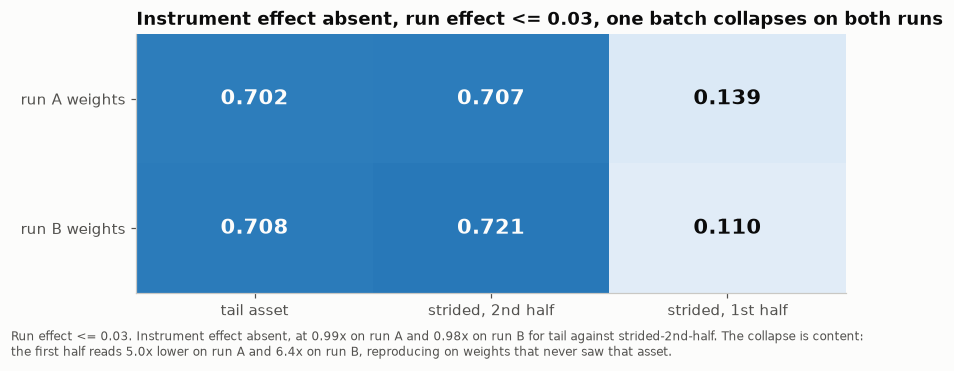

In [4]:
rows = load("crossprobe_2x2_matched-16384_step500.csv")
cell = defaultdict(list)
for r in rows:
    cell[(r["run"], f"{r['asset']}/{r['half']}")].append(num(r, "corr_bias_price"))
columns = ["tail/h1", "strided/h2", "strided/h1"]
labels = ["tail asset", "strided, 2nd half", "strided, 1st half"]
grid = np.array([[float(np.mean(cell[(run, c)])) for c in columns] for run in ("a", "b")])

fig, ax = plt.subplots(figsize=(7.8, 3.1))
ax.imshow(grid, cmap="Blues", vmin=0, vmax=1, aspect="auto")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax.text(
            j,
            i,
            f"{grid[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=14,
            color="#fcfcfb" if grid[i, j] > 0.55 else INK,
            fontweight="bold",
        )
ax.set_xticks(range(3), labels)
ax.set_yticks(range(2), ["run A weights", "run B weights"])
ax.set_title(
    f"Instrument effect absent, run effect <= {np.abs(grid[0] - grid[1]).max():.2f}, "
    "one batch collapses on both runs"
)
ax.grid(False)
fig.text(
    0.008,
    -0.06,
    f"Run effect <= {np.abs(grid[0] - grid[1]).max():.2f}. Instrument effect absent, at "
    f"{grid[0, 0] / grid[0, 1]:.2f}x on run A and {grid[1, 0] / grid[1, 1]:.2f}x on run B for "
    "tail against strided-2nd-half. The collapse is content:\n"
    f"the first half reads {grid[0, 0] / grid[0, 2]:.1f}x lower on run A and "
    f"{grid[1, 0] / grid[1, 2]:.1f}x on run B, reproducing on weights that never saw that asset.",
    fontsize=8,
    color=MUTED,
)
fig.tight_layout()
plt.show()

---
## 4. The headline: `kappa` over training, against the floor its own step size imposes

`kappa` comes from `kappa^2 = c_A * c_B / rho`, in which the two unknown batch noises cancel
exactly. The **ceiling** is what the measured bias jitter would permit if every bit of that motion
were noise orthogonal to the target, `kappa_max = V / sqrt(V^2 + sigma_b^2)`.

`kappa` is about 0.95 once balancing settles and about 0.81 by step 500. The ceiling is drawn as
a **curve** rather than a level, because `V` is not constant: the price signal shrinks from about
27 eta at step 100 to about 12 eta at step 500 while the jitter holds near 6 eta, so a ceiling
frozen at its last value would forbid early steps that in fact sit comfortably under a much higher
one. Part of the decline in `kappa` is therefore the falling ceiling. Read the **gap** between the
blue line and the dashed curve, which is the part the noise floor cannot account for.

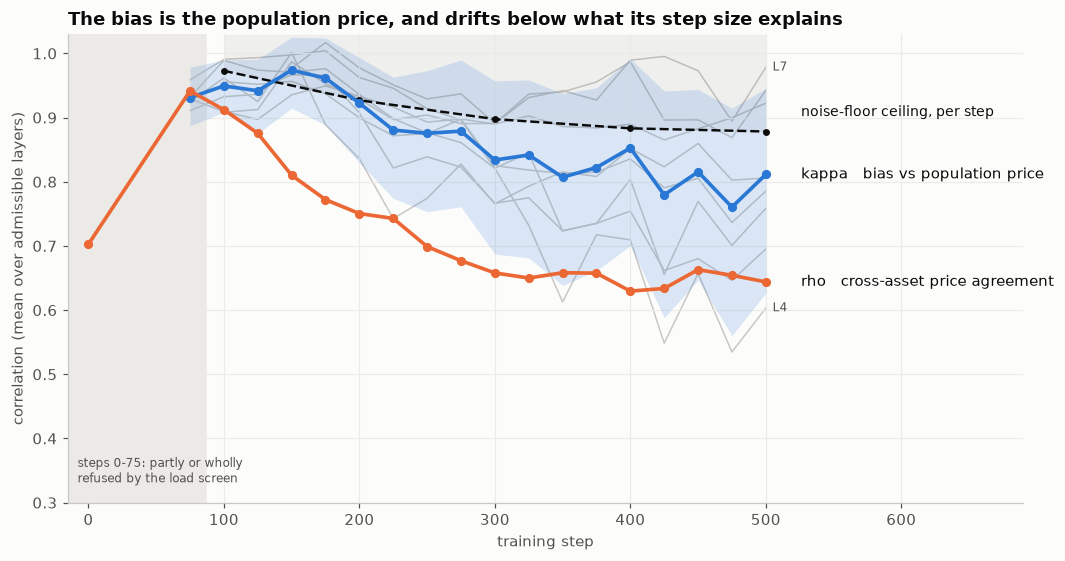

kappa 0.931 at step 75 -> 0.811 at step 500, against a ceiling that itself falls 0.973 -> 0.878


In [5]:
traj = load("kappa-trajectory_cross-asset_21-steps.csv")
jitter = {
    int(r["layer"]): num(r, "jitter_detrended_w5")
    for r in load("bias-jitter_both-runs_per-layer.csv")
    if "195028" in r["run"]
}

admissible = [r for r in traj if r["admissible"] == "True"]
steps = sorted({int(r["step"]) for r in admissible})


def mean_at(step, key):
    values = [num(r, key) for r in admissible if int(r["step"]) == step]
    values = [v for v in values if v == v]
    return float(np.mean(values)) if values else float("nan")


kappa = [mean_at(s, "kappa") for s in steps]
rho = [mean_at(s, "rho") for s in steps]
low = [mean_at(s, "kappa_boot_low") for s in steps]
high = [mean_at(s, "kappa_boot_high") for s in steps]

# The per-layer ceiling kappa_max = V / sqrt(V^2 + sigma_b^2), evaluated at every step V was
# measured rather than frozen at the last one, because V shrinks by half over the run and a frozen
# ceiling forbids early steps that sit under a much higher one. V is proxied by the spread of a
# sound batch's prices, which OVERSTATES the signal because it carries batch noise too, so the
# ceiling is generous and both failure directions below are conservative.
spread = [r for r in load("price-spread_both-probes_trajectory.csv") if r["instrument"] == "tail"]
ceiling_steps = sorted({int(r["step"]) for r in spread} & set(steps))
LATE = ceiling_steps[-2:]


def signal(step, layer):
    return next(
        num(r, "std") / ETA for r in spread if int(r["step"]) == step and int(r["layer"]) == layer
    )


def ceiling_at(step, layer):
    V = signal(step, layer)
    return V / np.sqrt(V**2 + jitter[layer] ** 2)


ceiling_curve = [
    float(np.mean([ceiling_at(s, layer) for layer in range(2, 10)])) for s in ceiling_steps
]
# The late window, which is the one section 5's per-layer table compares its late kappa against.
ceiling_by_layer = [float(np.mean([ceiling_at(s, layer) for s in LATE])) for layer in range(2, 10)]
signal_by_layer = [float(np.mean([signal(s, layer) for s in LATE])) for layer in range(2, 10)]
ceiling = ceiling_curve[-1]

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.axvspan(-15, 87, color="#eceae6", zorder=0)
ax.annotate(
    "steps 0-75: partly or wholly\nrefused by the load screen",
    (-8, 0.325),
    fontsize=8,
    color=MUTED,
    va="bottom",
)

for layer in range(2, 10):
    series = [
        next(
            (
                num(r, "kappa")
                for r in admissible
                if int(r["step"]) == s and int(r["layer"]) == layer
            ),
            np.nan,
        )
        for s in steps
    ]
    ax.plot(steps, series, color=FAINT, lw=1, zorder=1)
    if layer in (4, 7):
        ax.annotate(f"L{layer}", (steps[-1] + 5, series[-1]), color=MUTED, fontsize=8, va="center")

ax.fill_between(steps, low, high, color=BLUE, alpha=0.16, lw=0, zorder=2)
ax.fill_between(ceiling_steps, ceiling_curve, 1.03, color=INK, alpha=0.05, lw=0, zorder=1)
ax.plot(steps, kappa, "-o", color=BLUE, lw=2.4, ms=5, zorder=4)
ax.plot(steps, rho, "-o", color=ORANGE, lw=2.4, ms=5, zorder=4)
ax.plot(ceiling_steps, ceiling_curve, color=INK, lw=1.6, ls="--", zorder=3)
ax.plot(ceiling_steps, ceiling_curve, "o", color=INK, ms=3.5, zorder=3)

ax.annotate(
    "kappa   bias vs population price",
    (steps[-1] + 26, kappa[-1]),
    color=INK,
    fontsize=10,
    va="center",
)
ax.annotate(
    "rho   cross-asset price agreement",
    (steps[-1] + 26, rho[-1]),
    color=INK,
    fontsize=10,
    va="center",
)
ax.annotate(
    "noise-floor ceiling, per step",
    (steps[-1] + 26, ceiling + 0.03),
    color=INK,
    fontsize=9,
    va="center",
)

ax.set_xlabel("training step")
ax.set_ylabel("correlation (mean over admissible layers)")
ax.set_title("The bias is the population price, and drifts below what its step size explains")
ax.set_xlim(-15, 690)
ax.set_ylim(0.30, 1.03)
late_kappa_by_layer = [
    float(
        np.mean(
            [
                num(r, "kappa")
                for r in admissible
                if int(r["step"]) >= LATE[0] and int(r["layer"]) == layer
            ]
        )
    )
    for layer in range(2, 10)
]
per_layer_gap = [c - k for c, k in zip(ceiling_by_layer, late_kappa_by_layer, strict=True)]


early_signal = float(np.mean([signal(ceiling_steps[0], n) for n in range(2, 10)]))


def gap_at(step):
    return ceiling_curve[ceiling_steps.index(step)] - mean_at(step, "kappa")


# fig.text(
#     0.008,
#     -0.09,
#     "Bold: mean over admissible layers. Band: mean per-layer bootstrap 95% CI. Thin grey: "
#     "single layers.\n"
#     f"The ceiling falls too, because the signal shrinks from {early_signal:.0f} to "
#     f"{np.mean(signal_by_layer):.0f} eta while the jitter holds near "
#     f"{np.mean(list(jitter.values())):.1f} eta. The part it cannot account for is the gap,\n"
#     f"which widens from {gap_at(ceiling_steps[0]):.2f} at step {ceiling_steps[0]} to "
#     f"{gap_at(ceiling_steps[-1]):.2f} at step {ceiling_steps[-1]}, and runs "
#     f"{min(per_layer_gap):+.2f} (L7, above its own ceiling and so impossible for noise\n"
#     f"orthogonal to the target) to {max(per_layer_gap):+.2f} (L4). Shaded: the region a pure "
#     "floor forbids.",
#     fontsize=8,
#     color=MUTED,
# )
fig.tight_layout()
plt.show()
print(
    f"kappa {kappa[1]:.3f} at step {steps[1]} -> {kappa[-1]:.3f} at step {steps[-1]}, "
    f"against a ceiling that itself falls {ceiling_curve[0]:.3f} -> {ceiling_curve[-1]:.3f}"
)

### 4b. The decay is layer-specific, which no uniform floor can produce

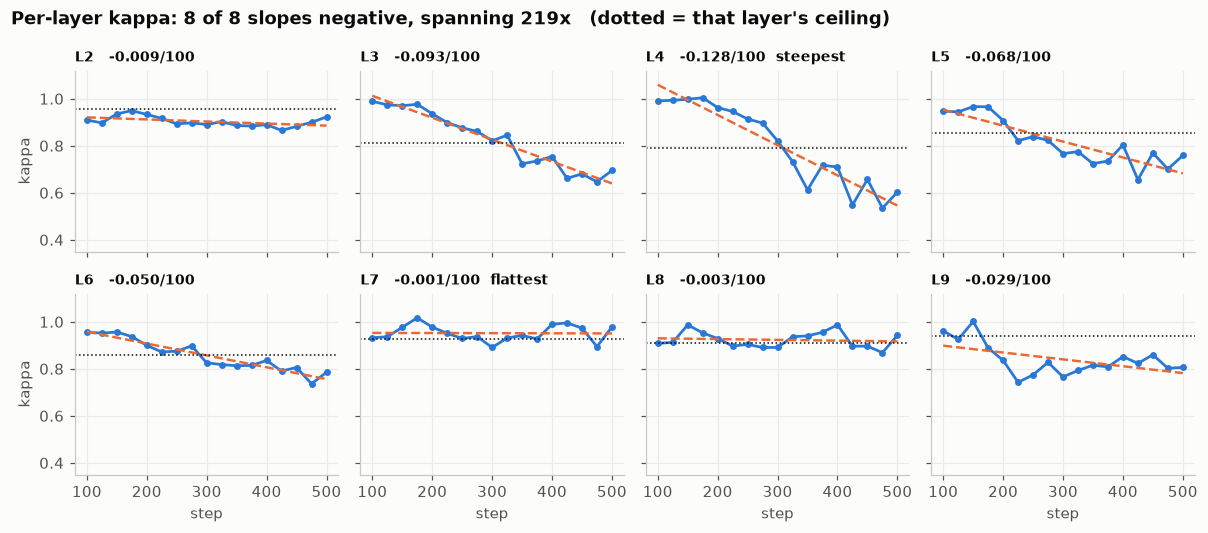

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(11, 4.9), sharex=True, sharey=True)
slopes = {}
for layer, ax in zip(range(2, 10), axes.ravel(), strict=True):
    xs = [s for s in steps if s >= 100]
    ys = [
        next(
            (
                num(r, "kappa")
                for r in admissible
                if int(r["step"]) == s and int(r["layer"]) == layer
            ),
            np.nan,
        )
        for s in xs
    ]
    fit = np.polyfit(xs, ys, 1)
    slopes[layer] = fit[0] * 100
    ax.plot(xs, ys, "-o", color=BLUE, lw=1.8, ms=3.5)
    ax.plot(xs, np.polyval(fit, xs), color=ORANGE, lw=1.6, ls="--")
    ax.axhline(ceiling_by_layer[layer - 2], color=INK, lw=1, ls=":")
    note = "  flattest" if layer == 7 else ("  steepest" if layer == 4 else "")
    ax.set_title(f"L{layer}   {fit[0] * 100:+.3f}/100{note}", fontsize=9)
    ax.set_ylim(0.35, 1.12)
for ax in axes[-1]:
    ax.set_xlabel("step")
axes[0, 0].set_ylabel("kappa")
axes[1, 0].set_ylabel("kappa")
fig.suptitle(
    "Per-layer kappa: 8 of 8 slopes negative, spanning 219x   (dotted = that layer's ceiling)",
    x=0.008,
    ha="left",
    fontsize=12,
    fontweight="bold",
)
fig.tight_layout()
plt.show()

---
## 5. The floor, measured, and why it is not the mechanism

Megatron's update is `expert_bias += sign(load_error) * eta`, so every training step moves every
expert by exactly `eta` and only the sign varies. Over the 25-step gap between dumps a memoryless
expert accumulates `sqrt(25) = 5 eta` and a steadily drifting one `25 eta`.

Run A is shown throughout. Run B agrees to within 0.16 eta on every layer, so nothing below turns
on the choice.

Two independent failures, in opposite directions, each on its own fatal to the floor story.

 L   V/eta  sigma_b/eta  ceiling  kappa late   verdict
 2    21.3         6.64    0.955       0.892   below ceiling, so drift
 3     8.9         6.40    0.811       0.688   below ceiling, so drift
 4     8.3         6.41    0.791       0.611   below ceiling, so drift
 5    10.2         6.20    0.854       0.738   below ceiling, so drift
 6    10.2         6.08    0.858       0.791   below ceiling, so drift
 7    14.2         5.77    0.927       0.966   ABOVE ceiling, impossible as noise
 8    12.8         5.85    0.910       0.918   at ceiling
 9    15.6         5.60    0.941       0.829   below ceiling, so drift

6 layers below their ceiling, 1 above it.
Below: the floor cannot push kappa that low, so something else degrades tracking.
Above: impossible if the motion were noise orthogonal to p_bar, so part of it is
the bias TRACKING a moving target, which the first-difference statistic booked as jitter.


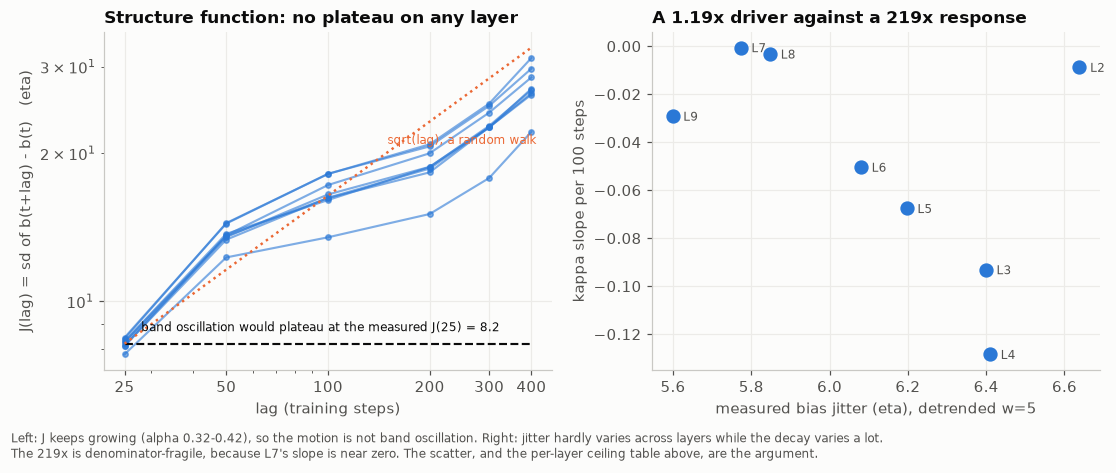

In [7]:
jrows = [r for r in load("bias-jitter_both-runs_per-layer.csv") if "195028" in r["run"]]
late = defaultdict(list)
for r in admissible:
    if int(r["step"]) >= 400:
        late[int(r["layer"])].append(num(r, "kappa"))

print(f"{'L':>2} {'V/eta':>7} {'sigma_b/eta':>12} {'ceiling':>8} {'kappa late':>11}   verdict")
below = above = 0
for layer in range(2, 10):
    observed = float(np.mean(late[layer]))
    limit = ceiling_by_layer[layer - 2]
    if observed < limit - 0.02:
        verdict, below = "below ceiling, so drift", below + 1
    elif observed > limit + 0.02:
        verdict, above = "ABOVE ceiling, impossible as noise", above + 1
    else:
        verdict = "at ceiling"
    print(
        f"{layer:2d} {signal_by_layer[layer - 2]:7.1f} {jitter[layer]:12.2f} {limit:8.3f} "
        f"{observed:11.3f}   {verdict}"
    )
print(f"\n{below} layers below their ceiling, {above} above it.")
print("Below: the floor cannot push kappa that low, so something else degrades tracking.")
print("Above: impossible if the motion were noise orthogonal to p_bar, so part of it is")
print("the bias TRACKING a moving target, which the first-difference statistic booked as jitter.")

LAGS = [1, 2, 4, 8, 12, 16]
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4))
ax = axes[0]
for r in jrows:
    ax.plot(
        [lag * 25 for lag in LAGS],
        [num(r, f"J_lag{lag}") for lag in LAGS],
        "-o",
        color=BLUE,
        lw=1.4,
        ms=3.5,
        alpha=0.6,
    )
lags = np.array([lag * 25 for lag in LAGS], dtype=float)
# Both reference lines are anchored at the measured J(25) rather than at a round number, so the
# comparison is against what the bias actually did over one dump gap.
J25 = float(np.mean([num(r, "J_lag1") for r in jrows]))
ax.plot(lags, np.full_like(lags, J25), color=INK, ls="--", lw=1.4)
ax.annotate(
    f"band oscillation would plateau at the measured J(25) = {J25:.1f}",
    (28, J25 * 1.06),
    fontsize=8,
    color=INK,
)
ax.plot(lags, J25 * np.sqrt(lags / 25), color=ORANGE, ls=":", lw=1.6)
ax.annotate(
    "sqrt(lag), a random walk", (150, J25 * np.sqrt(150 / 25) * 1.04), fontsize=8, color=ORANGE
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(lags)
ax.set_xticklabels([f"{int(v)}" for v in lags])
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xlabel("lag (training steps)")
ax.set_ylabel("J(lag) = sd of b(t+lag) - b(t)   (eta)")
ax.set_title("Structure function: no plateau on any layer", fontsize=11)

ax = axes[1]
ax.scatter(
    [jitter[n] for n in range(2, 10)], [slopes[n] for n in range(2, 10)], s=70, color=BLUE, zorder=3
)
for layer in range(2, 10):
    ax.annotate(
        f"L{layer}",
        (jitter[layer], slopes[layer]),
        textcoords="offset points",
        xytext=(7, -3),
        fontsize=8,
        color=MUTED,
    )
ax.set_xlabel("measured bias jitter (eta), detrended w=5")
ax.set_ylabel("kappa slope per 100 steps")
jitter_ratio = max(jitter.values()) / min(jitter.values())
slope_ratio = max(abs(v) for v in slopes.values()) / min(abs(v) for v in slopes.values())
ax.set_title(f"A {jitter_ratio:.2f}x driver against a {slope_ratio:.0f}x response", fontsize=11)
fig.text(
    0.008,
    -0.055,
    "Left: J keeps growing (alpha 0.32-0.42), so the motion is not band oscillation. Right: jitter "
    "hardly varies across layers while the decay varies a lot.\n"
    f"The {slope_ratio:.0f}x is denominator-fragile, because L7's slope is near zero. The scatter, "
    "and the per-layer ceiling table above, are the argument.",
    fontsize=8,
    color=MUTED,
)
fig.tight_layout()
plt.show()

---
## 6. Methods: why the intervals are bootstrapped rather than Fisher-z

Fisher-z assumes i.i.d. bivariate-normal pairs. These 64 expert prices come out of **one** joint LP
solve, which couples them through capacity, and are then mean-centred. The two intervals differ in
*location*, not only in width.

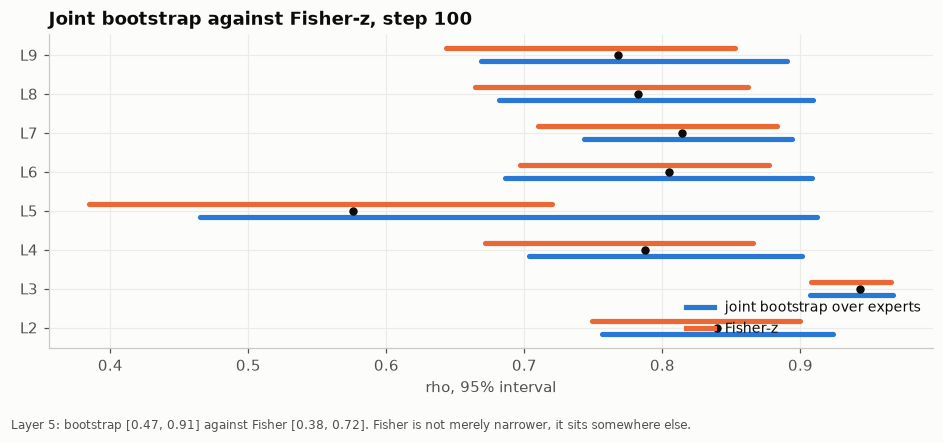

In [8]:
rows = sorted(
    [r for r in load("half-split_strided-probe_bootstrap_4-steps.csv") if int(r["step"]) == 100],
    key=lambda r: int(r["layer"]),
)
fig, ax = plt.subplots(figsize=(8.6, 3.8))
for i, r in enumerate(rows):
    ax.plot(
        [num(r, "rho_fisher_low"), num(r, "rho_fisher_high")],
        [i + 0.17] * 2,
        color=ORANGE,
        lw=3.4,
        solid_capstyle="round",
    )
    ax.plot(
        [num(r, "rho_boot_low"), num(r, "rho_boot_high")],
        [i - 0.17] * 2,
        color=BLUE,
        lw=3.4,
        solid_capstyle="round",
    )
    ax.plot([num(r, "rho")], [i], "o", color=INK, ms=4.5, zorder=4)
ax.set_yticks(range(len(rows)), [f"L{r['layer']}" for r in rows])
ax.set_xlabel("rho, 95% interval")
ax.set_title("Joint bootstrap against Fisher-z, step 100")
ax.plot([], [], color=BLUE, lw=3.4, label="joint bootstrap over experts")
ax.plot([], [], color=ORANGE, lw=3.4, label="Fisher-z")
ax.legend(frameon=False, loc="lower right", fontsize=9)
fig.text(
    0.008,
    -0.04,
    "Layer 5: bootstrap [0.47, 0.91] against Fisher [0.38, 0.72]. Fisher is not "
    "merely narrower, it sits somewhere else.",
    fontsize=8,
    color=MUTED,
)
fig.tight_layout()
plt.show()

---
## Where this leaves the thesis

1. **The mechanism reaches the optimum.** The annealed ALF-LB replica against the LP oracle: dual
   correlation 1.000000, primal residual 0.056% of `n*K`.
2. **The bias is the population price**, at `kappa` about 0.95 once balancing settles, recovered
   with no free parameter from batches that never observe `p_bar`.
3. **That tracking decays over training**, 0.95 to 0.81, with 8 of 8 per-layer slopes negative.
   Some of that decline is a falling ceiling rather than worse tracking, because the price signal
   halves over the run while the jitter does not.
4. **The residual is not the O(eta) floor.** The gap to the per-step ceiling widens from 0.02 to
   0.07, six layers sit *below* the ceiling their measured jitter allows, one sits *above* it
   (impossible for orthogonal noise), `J(lag)` never plateaus, and the lag-1 autocorrelation is
   positive. The bias is a **lagging tracker of a moving target**, with layer-specific target
   speeds.

**Open, and O2 is now a clean discriminator.** Annealing the learning rate freezes the affinities
while leaving `eta`, and so the floor, untouched. A floor story predicts no recovery in `kappa`. A
lag story predicts recovery. They differ in sign rather than in degree.